In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics.data.augment import LetterBox
import torch

In [2]:
image_path = "bus.jpg"

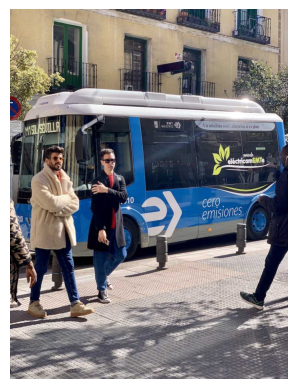

In [12]:
img = cv2.imread(image_path)                 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [5]:
img.shape

(1080, 810, 3)

In [7]:
device = "cuda:0"
model_fp16 = False

In [9]:
def preprocess(im: torch.Tensor | list[np.ndarray]) -> torch.Tensor:
    not_tensor = not isinstance(im, torch.Tensor)
    if not_tensor:
        im = np.stack(pre_transform(im))
        if im.shape[-1] == 3:
            im = im[..., ::-1]  # BGR to RGB
        im = im.transpose((0, 3, 1, 2))  # BHWC to BCHW, (n, 3, h, w)
        im = np.ascontiguousarray(im)  # contiguous
        im = torch.from_numpy(im)

    im = im.to(device)
    im = im.half() if model_fp16 else im.float()  # uint8 to fp16/32
    if not_tensor:
        im /= 255  # 0 - 255 to 0.0 - 1.0
    return im

def pre_transform(im: list[np.ndarray]) -> list[np.ndarray]:
    letterbox = LetterBox(
        (640, 640),
        auto=len({x.shape for x in im}) == 1,
        stride=32,
    )
    return [letterbox(image=x) for x in im]

In [19]:
image_path = "bus.jpg"
img = cv2.imread(image_path)
img = np.array([img])
im = preprocess(img)

In [20]:
im.shape

torch.Size([1, 3, 640, 480])

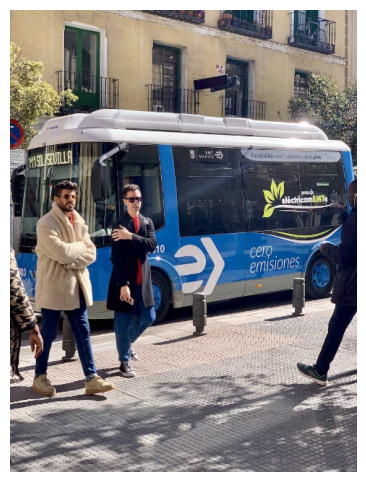

In [21]:
img_vis = im[0].permute(1, 2, 0).cpu().numpy()  # CHW -> HWC

plt.figure(figsize=(6, 6))
plt.imshow(img_vis)
plt.axis("off")
plt.show()

In [23]:
img_vis.shape

(640, 480, 3)